In [490]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from imblearn.under_sampling import TomekLinks

In [330]:
def get_regular_bounds(column_data: pd.Series):
    Q1 = column_data.quantile(0.25)
    Q3 = column_data.quantile(0.75)
    IQR = Q3 - Q1

    min_value = (Q1 - 1.5 * IQR)
    max_value = (Q3 + 1.5 * IQR)

    return {'min': min_value, 'max': max_value}

In [331]:
# Function to calculate AUROC and show ROC curve
def get_auroc(target, probs):
    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])

    plt.plot(fpr, tpr)
    plt.show()

    auroc = auc(fpr, tpr)

    return auroc

In [332]:
raw_df = pd.read_csv('bank-additional-full.csv', sep=';')
raw_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [333]:
# Check whether target values are balanced
raw_df.y.value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [334]:
# Split dataset into train, validation and test
target_col = 'y'

train_val_df, test_df = train_test_split(
    raw_df,
    test_size=0.2,
    stratify=raw_df[target_col],
    random_state=15
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    stratify=train_val_df[target_col],
    random_state=15
)

train_df.shape, val_df.shape, test_df.shape

((24712, 21), (8238, 21), (8238, 21))

# Explorartory Data Analysis

In [335]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24712 entries, 31774 to 39644
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             24712 non-null  int64  
 1   job             24712 non-null  object 
 2   marital         24712 non-null  object 
 3   education       24712 non-null  object 
 4   default         24712 non-null  object 
 5   housing         24712 non-null  object 
 6   loan            24712 non-null  object 
 7   contact         24712 non-null  object 
 8   month           24712 non-null  object 
 9   day_of_week     24712 non-null  object 
 10  duration        24712 non-null  int64  
 11  campaign        24712 non-null  int64  
 12  pdays           24712 non-null  int64  
 13  previous        24712 non-null  int64  
 14  poutcome        24712 non-null  object 
 15  emp.var.rate    24712 non-null  float64
 16  cons.price.idx  24712 non-null  float64
 17  cons.conf.idx   24712 non-null  

In [336]:
# Separate input columns and from them: numeric and categorical
input_cols = train_df.columns.drop([target_col]).to_list()
numeric_cols = train_df[input_cols].select_dtypes(include='number').columns.to_list()
categorical_cols = train_df[input_cols].select_dtypes(include='object').columns.to_list()
len(numeric_cols), len(categorical_cols)

(10, 10)

In [337]:
# Transform target to numeric values
target_map = {'yes': 1, 'no': 0}
train_df[target_col] = train_df[target_col].map(target_map)
val_df[target_col] = val_df[target_col].map(target_map)

val_df[target_col]

34950    0
20110    0
34275    1
19336    0
16625    0
        ..
1293     0
15543    0
11774    0
37508    0
3967     0
Name: y, Length: 8238, dtype: int64

## Numeric columns

In [338]:
train_df[numeric_cols].nunique()

age                 76
duration          1378
campaign            39
pdays               25
previous             8
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          308
nr.employed         11
dtype: int64

In [339]:
train_df[numeric_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000,24712.000000
mean,40.035934,257.453585,2.566891,962.311509,0.170889,0.080876,93.577196,-40.504969,3.620135,5166.899992
std,10.444823,258.762131,2.803634,187.320756,0.489927,1.570207,0.579355,4.635223,1.734653,72.232444
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


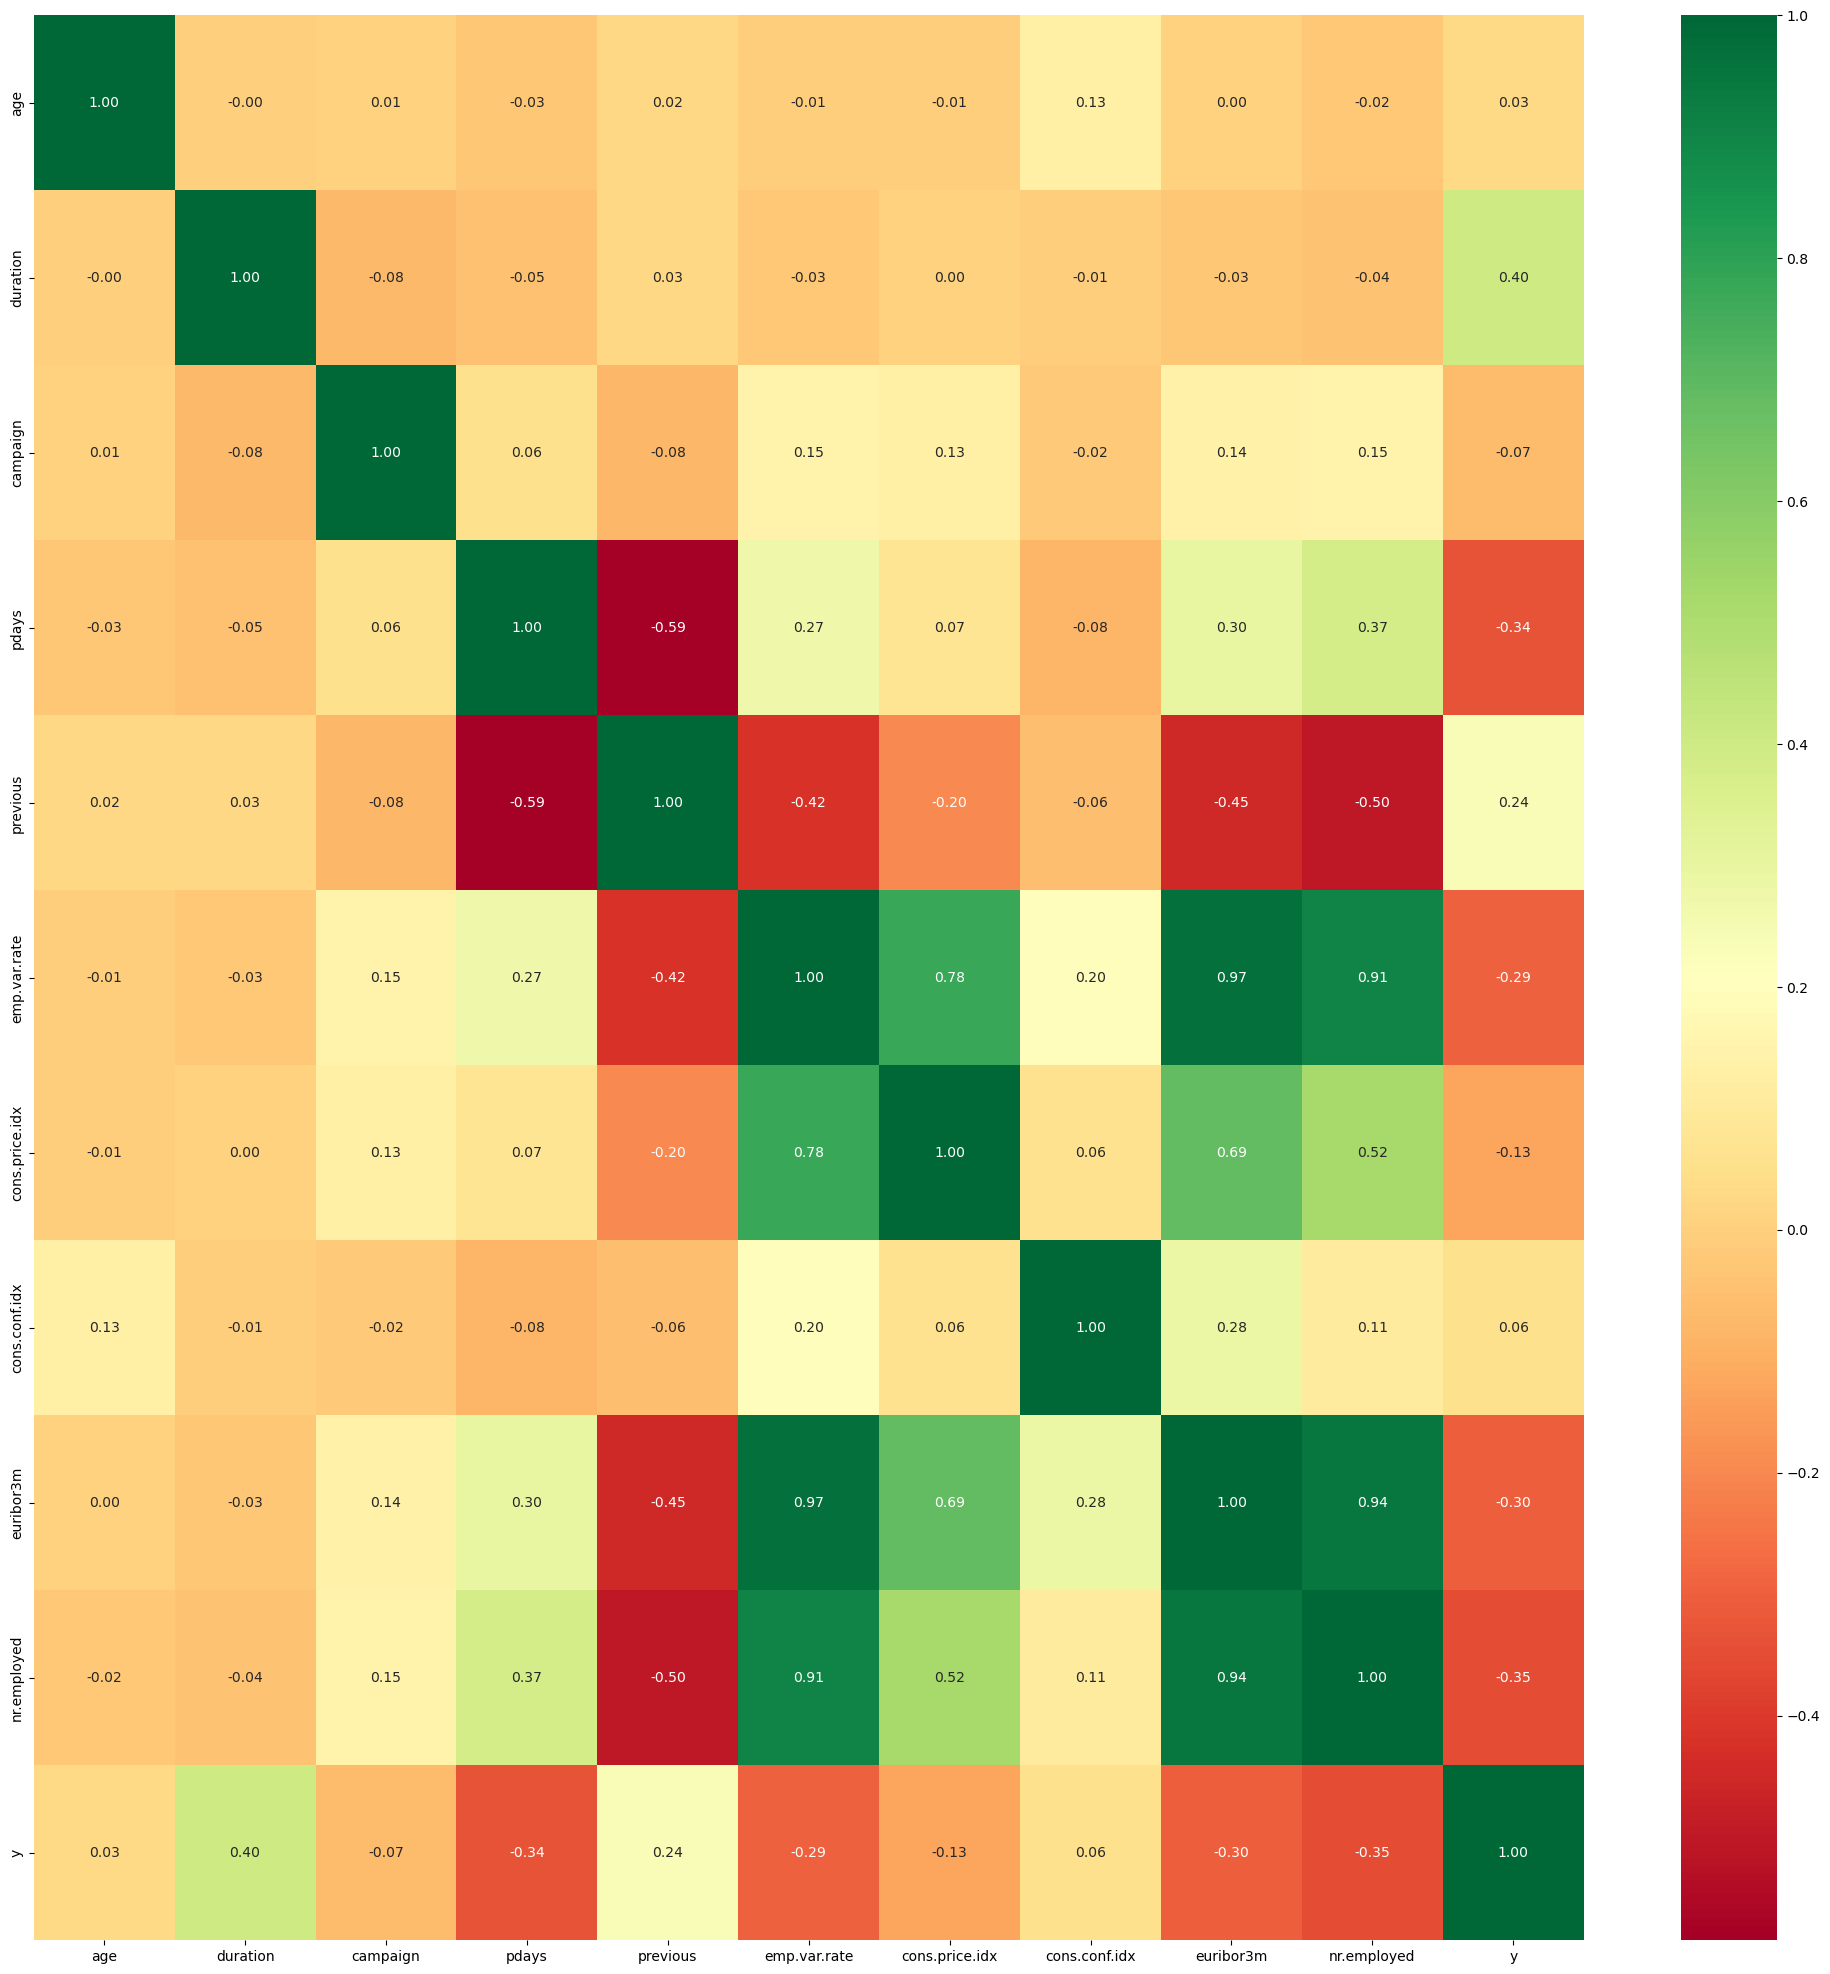

In [340]:
corr_num_train = train_df[[*numeric_cols, target_col]].corr()

plt.figure(figsize=(25, 25))
sns.heatmap(data=corr_num_train, annot=True, cmap="RdYlGn", cbar=True, fmt='.2f')
plt.show()

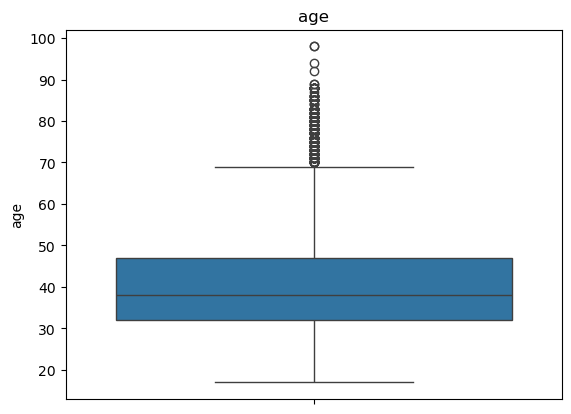

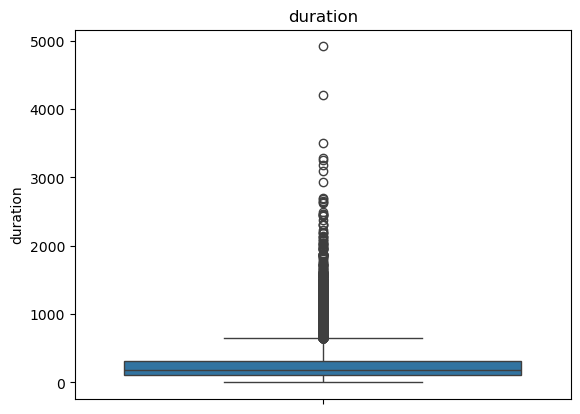

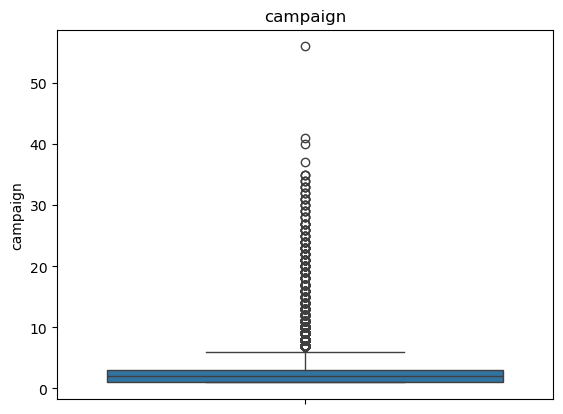

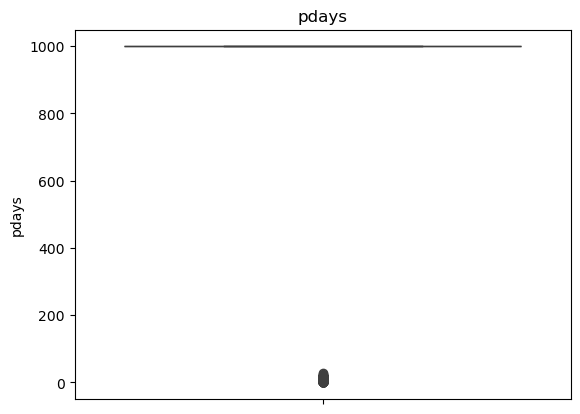

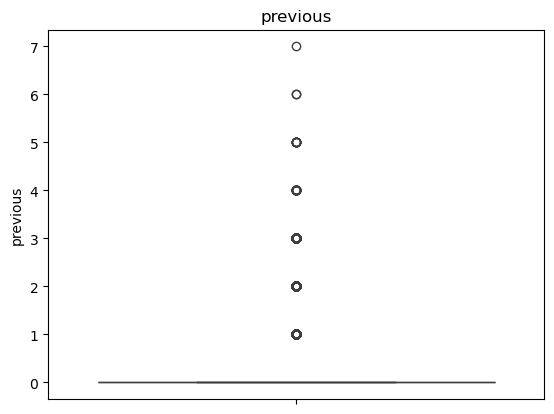

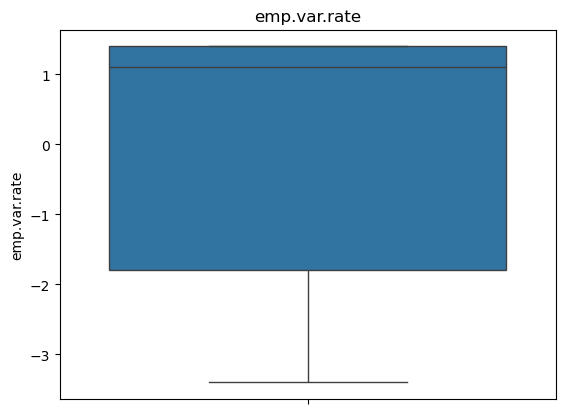

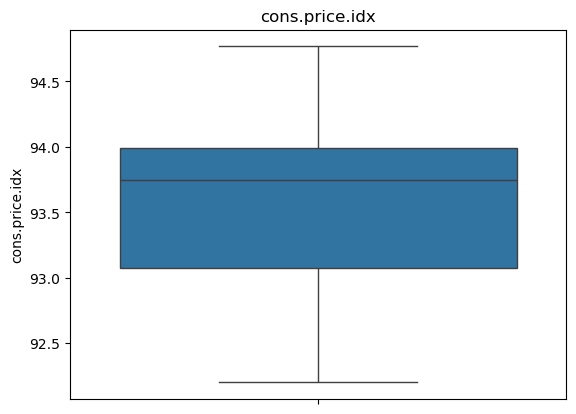

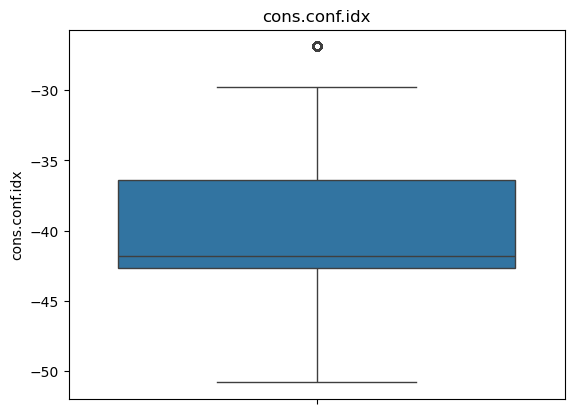

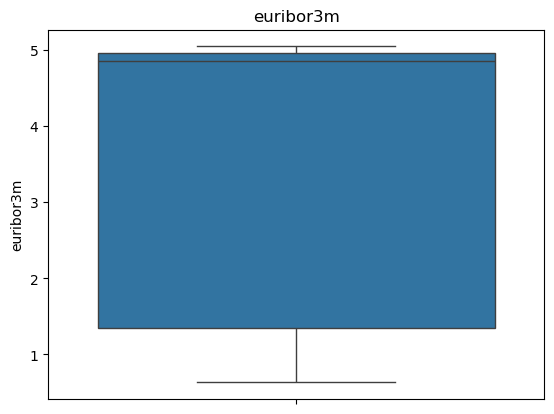

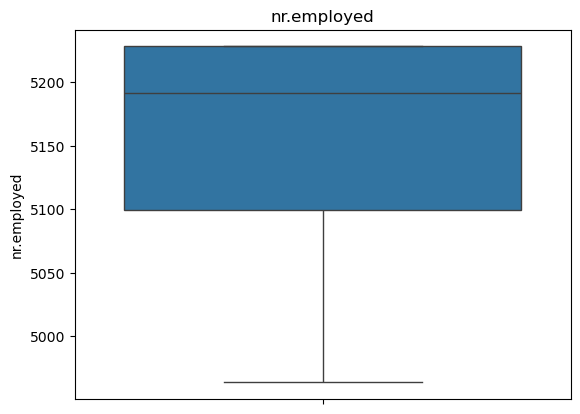

In [341]:
for col in numeric_cols:
    sns.boxplot(train_df[col])
    plt.title(col)
    plt.show()

### `age` column

In [342]:
train_df['age'].describe()

count    24712.000000
mean        40.035934
std         10.444823
min         17.000000
25%         32.000000
50%         38.000000
75%         47.000000
max         98.000000
Name: age, dtype: float64

In [343]:
print(get_regular_bounds(train_df['age']))

{'min': np.float64(9.5), 'max': np.float64(69.5)}


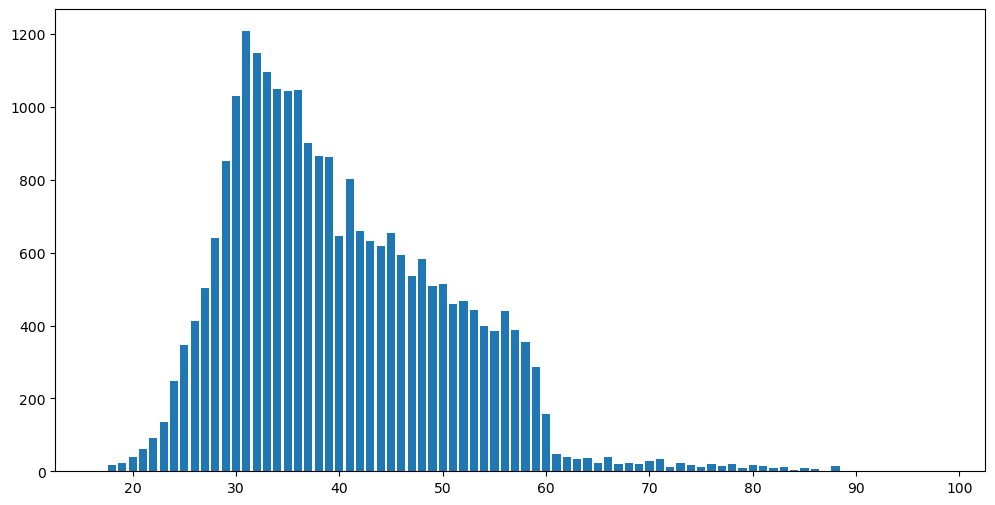

In [344]:
age_value_counts = train_df['age'].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(age_value_counts.index, age_value_counts.values)
plt.show()

**Summary**
Ages 70 and more are outliers. It makes sense to create additional categorical feature with age ranges.

#### Create `age_ranges`

In [468]:
def age_cat(years):
    if years < 21:
        return '0-20'
    elif years >= 21 and years < 30:
        return '21-29'
    elif years >= 30 and years < 35:
        return '30-34'
    elif years >= 35 and years < 40:
        return '35-39'
    elif years >= 40 and years < 50:
        return '40-49'
    elif years >= 50 and years < 60:
        return '50-59'
    elif years >= 60 and years < 70:
        return '60-69'
    elif years >= 70:
        return '70+'

In [346]:
age_ranges = train_df['age'].apply(age_cat)
age_ranges

31774    21-29
18637    30-34
12921    30-34
40295    30-34
15037    30-34
         ...  
3903     50-59
29429    35-39
40741    21-29
9725     40-49
39644    40-49
Name: age, Length: 24712, dtype: object

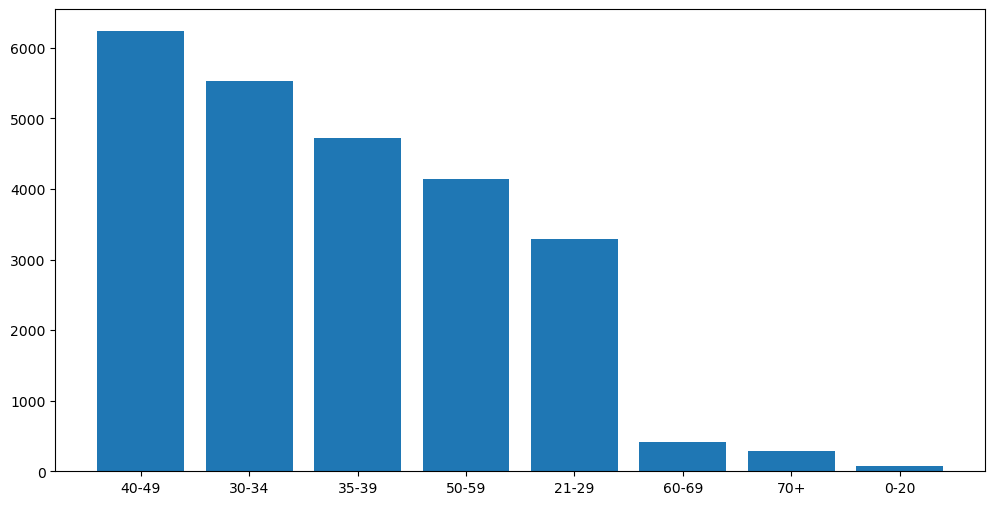

In [469]:
age_cat_value_counts = age_ranges.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(age_cat_value_counts.index.astype('str'), age_cat_value_counts.values)
plt.show()

### `duration` column

In [348]:
train_df['duration'].describe(percentiles=[0.75, 0.95, 0.99, 0.999])

count    24712.000000
mean       257.453585
std        258.762131
min          0.000000
50%        179.000000
75%        318.000000
95%        752.450000
99%       1271.000000
99.9%     2191.624000
max       4918.000000
Name: duration, dtype: float64

In [349]:
print(get_regular_bounds(train_df['duration']))

{'min': np.float64(-222.0), 'max': np.float64(642.0)}


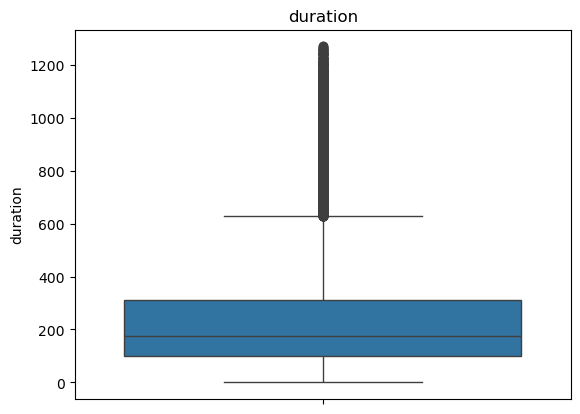

In [350]:
# Let's check boxplot for 99% percentile
train_duration_99_percentile = train_df[train_df['duration'] <= 1271]['duration']
sns.boxplot(train_duration_99_percentile)
plt.title('duration')
plt.show()

**Summary**
Values over 1271 for `duration` are outliers for sure. But we want do anything with this column because it can be used for benchmark only.

### `pdays` column

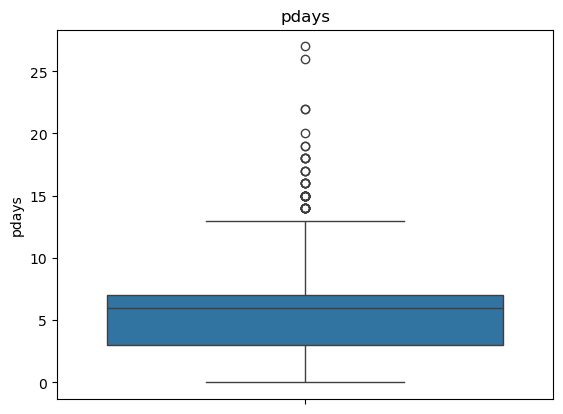

In [351]:
# In 'pdays' value 999 means no previous contact,
# let's build boxplot without it
train_pdays_no999 = train_df[train_df['pdays'] != 999]['pdays']
sns.boxplot(train_pdays_no999)
plt.title('pdays')
plt.show()

In [352]:
train_df['pdays'].value_counts()

pdays
999    23799
3        269
6        248
4         70
9         43
2         38
7         35
12        34
10        33
5         25
13        25
15        16
11        14
1         14
0         12
14        10
8          8
16         5
18         4
17         3
22         2
19         2
20         1
27         1
26         1
Name: count, dtype: int64

In [353]:
print(get_regular_bounds(train_pdays_no999))

{'min': np.float64(-3.0), 'max': np.float64(13.0)}


**Summary**
- Value 999 for `pdays` should be treated differently.
- Most of the data has this special value.
- Values >13 are outliers.
- The values apart from 999 are rare, we can create additional binary feature (999 vs other).

### `previous` column

In [354]:
train_df['previous'].value_counts()

previous
0    21369
1     2711
2      449
3      135
4       35
5       10
6        2
7        1
Name: count, dtype: int64

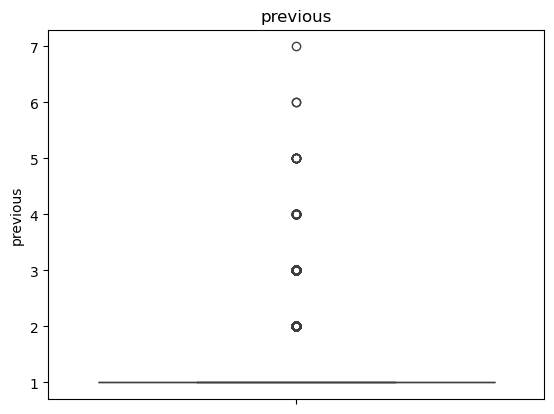

In [355]:
# In 'previous' most values are equal to 0 - no previous contact,
# let's check boxplot without it
train_previous_no0 = train_df[train_df['previous'] != 0]['previous']
sns.boxplot(train_previous_no0)
plt.title('previous')
plt.show()

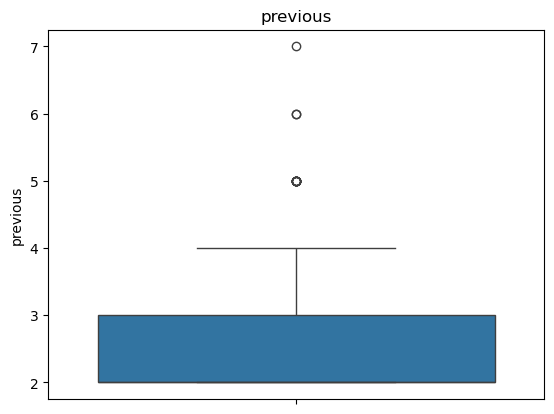

In [356]:
# Most values apart 0, are 1. Let's check without both
train_previous_no01 = train_df[(train_df['previous'] != 0) & (train_df['previous'] != 1)]['previous']
sns.boxplot(train_previous_no01)
plt.title('previous')
plt.show()

**Summary**
- Most of the instances have value 0 in `previous`.
- Most of the instances apart of 0 have value 1.
- It makes sense to create additional feature where values >1 will be merged into one.
- Value 0 for `previous` and value 999 for `pdays` might have the same meaning, but number of these values is different. Needs to be investigated.

#### Check `pdays` and `previous` discrepancy

In [357]:
# Check `previous` values !=0 in instances
# that have value 999 in `pdays`
train_df[
    (train_df['pdays'] == 999)
    & (train_df['previous'] != 0)
    ]['previous'].value_counts()

previous
1    2181
2     208
3      32
4       7
5       2
Name: count, dtype: int64

**Summary**
- Looks like instances with `pdays`=999 and `previous`!=0 have an error and should have different value in `pdays`.
- In the additional binary feature for `pdays` we can mark these instances as 'was contacted'.

### `campaign` column

In [358]:
print(get_regular_bounds(train_df['campaign']))

{'min': np.float64(-2.0), 'max': np.float64(6.0)}


In [359]:
train_df['campaign'].value_counts()

campaign
1     10636
2      6357
3      3171
4      1617
5       946
6       558
7       343
8       241
9       163
10      132
11       97
12       84
13       62
14       44
17       38
15       38
16       26
18       21
19       20
20       18
21       14
23       12
24       11
22       10
27        7
25        6
26        6
31        5
33        4
28        4
29        4
30        4
35        3
34        3
32        3
41        1
40        1
37        1
56        1
Name: count, dtype: int64

**Summary**
- Values >6 are outliers.
- Makes sense to put (some of) them into one category.

## Categorical columns

In [360]:
train_df[categorical_cols].nunique()

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64

In [361]:
for col in categorical_cols:
    print(train_df[col].value_counts())
    print('\n')

job
admin.           6256
blue-collar      5614
technician       3973
services         2391
management       1740
retired          1035
entrepreneur      897
self-employed     858
housemaid         630
unemployed        599
student           513
unknown           206
Name: count, dtype: int64


marital
married     14951
single       6919
divorced     2794
unknown        48
Name: count, dtype: int64


education
university.degree      7260
high.school            5673
basic.9y               3632
professional.course    3140
basic.4y               2519
basic.6y               1414
unknown                1062
illiterate               12
Name: count, dtype: int64


default
no         19499
unknown     5211
yes            2
Name: count, dtype: int64


housing
yes        12995
no         11106
unknown      611
Name: count, dtype: int64


loan
no         20347
yes         3754
unknown      611
Name: count, dtype: int64


contact
cellular     15604
telephone     9108
Name: count, dtype: int64


mo

### `default` column

In [362]:
train_df[train_df['default'] == 'yes']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
24866,31,unemployed,married,high.school,yes,no,no,cellular,nov,tue,...,2,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,0
21580,48,technician,married,professional.course,yes,no,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0


In [363]:
train_df.groupby('default')[target_col].mean()

default
no         0.128878
unknown    0.052005
yes        0.000000
Name: y, dtype: float64

In [364]:
train_df.groupby('default')[target_col].agg(
    count='count',
    positive='sum',
    positive_rate='mean'
)

,count,positive,positive_rate
default,,,
no,19499,2513,0.128878
unknown,5211,271,0.052005
yes,2,0,0.000000


**Summary**
- There are only 2 instances with `default`='yes'. And both of them have target value of 0.
- Instances with 'unknown' value are closer to target value 0, but still not equals to 'yes'.
- I won't change this column.

### Encoding

In [365]:
# Encode categorical columns with OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(train_df[categorical_cols])

encoded_cols = ohe.get_feature_names_out().tolist()

train_encoded_df = pd.DataFrame(
        ohe.transform(train_df[categorical_cols]),
        columns=encoded_cols,
        index=train_df.index
)
train_encoded_df

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
31774,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
40295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
15037,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
29429,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
40741,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9725,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [366]:
# Check correlation with target for encoded columns
corr_cat_train = pd.concat([train_encoded_df, train_df[target_col]], axis=1).corr()

corr_cat_train[target_col].sort_values(ascending=False, key=abs)

y                                1.000000
poutcome_success                 0.327572
poutcome_nonexistent            -0.201468
month_oct                        0.143607
contact_cellular                 0.143022
contact_telephone               -0.143022
month_mar                        0.137281
month_sep                        0.136164
month_may                       -0.118197
default_no                       0.099221
default_unknown                 -0.099164
job_student                      0.090850
job_retired                      0.088425
month_dec                        0.082827
month_apr                        0.081497
job_blue-collar                 -0.070395
marital_single                   0.058870
education_basic.9y              -0.048860
education_university.degree      0.046954
marital_married                 -0.046694
job_services                    -0.039123
job_admin.                       0.035678
month_jul                       -0.033765
poutcome_failure                 0

In [367]:
# Check correlation with target for both numeric and encoded categorical columns
corr_all_train = pd.concat(
    [corr_num_train.drop('y', axis=0),
     corr_cat_train.drop('y', axis=0)],
    axis=0
)

corr_all_train[target_col].sort_values(ascending=False, key=abs).head(20)

duration                0.401902
nr.employed            -0.352680
pdays                  -0.335995
poutcome_success        0.327572
euribor3m              -0.303276
emp.var.rate           -0.294937
previous                0.235444
poutcome_nonexistent   -0.201468
month_oct               0.143607
contact_cellular        0.143022
contact_telephone      -0.143022
month_mar               0.137281
month_sep               0.136164
cons.price.idx         -0.131605
month_may              -0.118197
default_no              0.099221
default_unknown        -0.099164
job_student             0.090850
job_retired             0.088425
month_dec               0.082827
Name: y, dtype: float64

# Metrics selection

In [368]:
train_df[target_col].value_counts()

y
0    21928
1     2784
Name: count, dtype: int64

- Target `y` answers the question: has the client subscribed a term deposit?
- This variable is binary and has values: 'yes' (positive) and 'no' (negative).

Errors:
- False Positive (FP) - model predicted that client would subscribe, but he didn't.
- False Negative (FN) - model predicted that client would NOT subscribe, but he did.

FP means that bank employees would spend time for a client which won't buy a service. FN means that bank would give up on a client who whould buy a service. Both errors have their cost, but FN is a missed opportunity, so it's more important to focus on minimizing this kind of error.

Our target classes are imbalanced with much bigger number of the negative values than of the positive ones.

For models comparison we can use ROC AUC score and then find the best threshold value with Recall (to minimize FN) / F1 score (to balance between FN and FP).

# Preprocessing

In [425]:
# Redefine input columns
input_cols = train_df.columns.drop([target_col, 'duration']).to_list()

len(input_cols)

19

In [426]:
# Define X-s and y-s
X_train = train_df[input_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[input_cols].copy()
y_val = val_df[target_col].copy()

In [470]:
# Create ranges categorial feature for age
X_train['age_range'] = X_train['age'].apply(age_cat)
X_val['age_range'] = X_val['age'].apply(age_cat)

In [428]:
# Create ordered category feature for campaign
X_train['campaign_category'] = [
    str(val)
    if val < 7
    else '7 or more'
    for val in X_train['campaign']
]
X_val['campaign_category'] = [
    str(val)
    if val < 7
    else '7 or more'
    for val in X_val['campaign']
]

campaign_cats = X_train['campaign_category'].unique().tolist()
campaign_cats.sort()
X_train['campaign_category'] = pd.Categorical(
    X_train['campaign_category'],
    categories=['0', *campaign_cats],  # added 0 to correspond categories with original values
    ordered=True
)
X_val['campaign_category'] = pd.Categorical(
    X_val['campaign_category'],
    categories=['0', *campaign_cats],
    ordered=True
)

In [429]:
# Create ordered category feature for previous
X_train['previous_category'] = [
    str(val)
    if val < 2
    else '2 or more'
    for val in X_train['previous']
]
X_val['previous_category'] = [
    str(val)
    if val < 2
    else '2 or more'
    for val in X_val['previous']
]

previous_cats = X_train['previous_category'].unique().tolist()
previous_cats.sort()
X_train['previous_category'] = pd.Categorical(
    X_train['previous_category'],
    categories=previous_cats,
    ordered=True
)
X_val['previous_category'] = pd.Categorical(
    X_val['previous_category'],
    categories=previous_cats,
    ordered=True
)

In [430]:
# Create binary feature for pdays
X_train['pdays_was_contacted'] = (
    ~((X_train['pdays'] == 999) & (X_train['previous'] == 0))
).astype(int)
X_val['pdays_was_contacted'] = (
    ~((X_val['pdays'] == 999) & (X_val['previous'] == 0))
).astype(int)

In [471]:
# Transform all object features to 'category' type
features_to_transform = X_train.select_dtypes(include=['object']).columns
X_train[features_to_transform] = X_train[features_to_transform].astype('category')
X_val[features_to_transform] = X_val[features_to_transform].astype('category')

# Make sure validation set has the same categories
for cat in features_to_transform:
    X_val[cat] = X_val[cat].cat.set_categories(
        X_train[cat].cat.categories
    )

In [472]:
# Redefine input, numeric and categorical columns
# and define ordered categorical columns separately
input_cols = X_train.columns.to_list()
numeric_cols = X_train[input_cols].select_dtypes(include='number').columns.to_list()
ordered_cols = ['campaign_category', 'previous_category']
categorical_cols = (
    X_train[input_cols]
    .select_dtypes(include='category')
    .columns
    .drop(ordered_cols)
    .to_list()
)

len(numeric_cols), len(categorical_cols), len(ordered_cols)

(10, 11, 2)

In [473]:
# Encode categorical columns with OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[categorical_cols])

encoded_cols = ohe.get_feature_names_out().tolist()

X_train_encoded = pd.DataFrame(
        ohe.transform(X_train[categorical_cols]),
        columns=encoded_cols,
        index=train_df.index
)

In [474]:
ord_encoder = OrdinalEncoder()
ord_encoder.fit(X_train[ordered_cols])

X_train_encoded[ordered_cols] = ord_encoder.transform(X_train[ordered_cols])
X_train_encoded

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,age_range_0-20,age_range_21-29,age_range_30-34,age_range_35-39,age_range_40-49,age_range_50-59,age_range_60-69,age_range_70+,campaign_category,previous_category
31774,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
12921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0
15037,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
29429,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
40741,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
9725,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0


In [477]:
# Check correlation with target for preprocessed columns
corr_cat_train = pd.concat([X_train_encoded, y_train], axis=1).corr()

corr_cat_train[target_col].sort_values(ascending=False, key=abs).head(30)

y                              1.000000
poutcome_success               0.327572
previous_category              0.233230
poutcome_nonexistent          -0.201468
month_oct                      0.143607
contact_cellular               0.143022
contact_telephone             -0.143022
month_mar                      0.137281
month_sep                      0.136164
age_range_70+                  0.122333
month_may                     -0.118197
age_range_60-69                0.102485
default_no                     0.099221
default_unknown               -0.099164
job_student                    0.090850
job_retired                    0.088425
month_dec                      0.082827
month_apr                      0.081497
campaign_category             -0.074722
job_blue-collar               -0.070395
age_range_40-49               -0.061741
marital_single                 0.058870
age_range_21-29                0.055188
education_basic.9y            -0.048860
education_university.degree    0.046954


# Logistic Regression

## After preprocessing

In [525]:
num_preprocessor = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_preprocessor = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ord_preprocessor = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

col_transformer = ColumnTransformer(transformers=[
    ('num', num_preprocessor, numeric_cols),
    ('cat', cat_preprocessor, categorical_cols),
    ('ord', ord_preprocessor, ordered_cols)
])

logistic_pipeline = Pipeline(steps=[
    ('transformer', col_transformer),
    ('classifier', LogisticRegression(random_state=987))
])

In [526]:
logistic_pipeline.fit(X_train, y_train)

train_preds = logistic_pipeline.predict(X_train)
val_preds = logistic_pipeline.predict(X_val)

train_probas = logistic_pipeline.predict_proba(X_train)
val_probas = logistic_pipeline.predict_proba(X_val)

### Metrics values

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     23716
           1       0.24      0.68      0.36       996

    accuracy                           0.90     24712
   macro avg       0.61      0.80      0.65     24712
weighted avg       0.96      0.90      0.92     24712



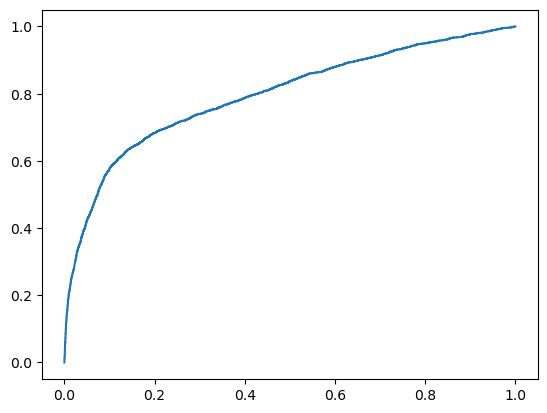

0.7960054237719475


In [527]:
print(classification_report(train_preds, y_train))
print(get_auroc(y_train, train_probas))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7929
           1       0.21      0.62      0.31       309

    accuracy                           0.90      8238
   macro avg       0.60      0.77      0.63      8238
weighted avg       0.96      0.90      0.92      8238



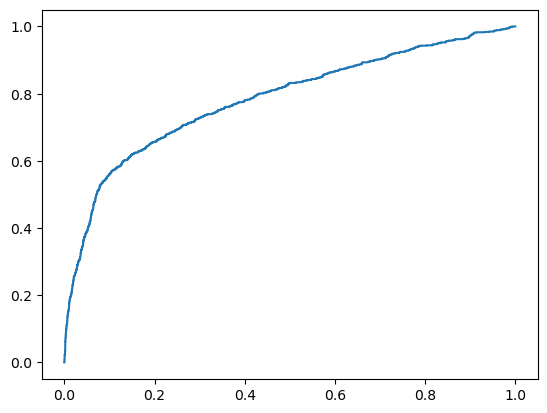

0.7837154759658475


In [528]:
print(classification_report(val_preds, y_val))
print(get_auroc(y_val, val_probas))

## PolynomialFeatures

In [529]:
num_preprocessor = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=3))
])

cat_preprocessor = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ord_preprocessor = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

col_transformer = ColumnTransformer(transformers=[
    ('num', num_preprocessor, numeric_cols),
    ('cat', cat_preprocessor, categorical_cols),
    ('ord', ord_preprocessor, ordered_cols)
])

logistic_pipeline = Pipeline(steps=[
    ('transformer', col_transformer),
    ('classifier', LogisticRegression(random_state=987, max_iter=200))
])

In [530]:
logistic_pipeline.fit(X_train, y_train)

train_preds = logistic_pipeline.predict(X_train)
val_preds = logistic_pipeline.predict(X_val)

train_probas = logistic_pipeline.predict_proba(X_train)
val_probas = logistic_pipeline.predict_proba(X_val)

In [531]:
logistic_pipeline.named_steps['classifier'].n_features_in_

349

### Metrics values

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     23711
           1       0.25      0.70      0.37      1001

    accuracy                           0.90     24712
   macro avg       0.62      0.81      0.66     24712
weighted avg       0.96      0.90      0.92     24712



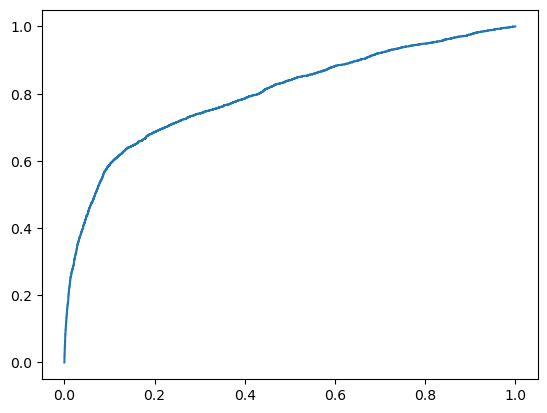

0.7992632284419856


In [532]:
print(classification_report(train_preds, y_train))
print(get_auroc(y_train, train_probas))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7915
           1       0.22      0.63      0.32       323

    accuracy                           0.90      8238
   macro avg       0.60      0.77      0.63      8238
weighted avg       0.95      0.90      0.92      8238



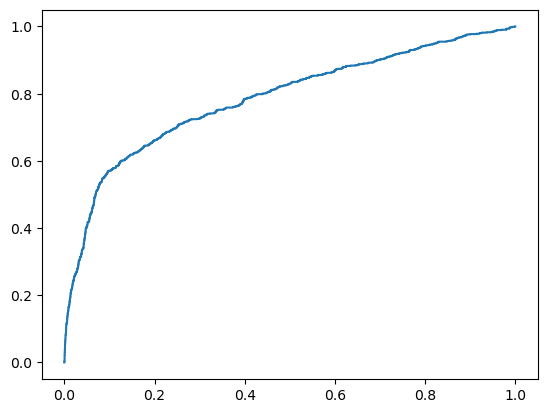

0.7855125831407141


In [533]:
print(classification_report(val_preds, y_val))
print(get_auroc(y_val, val_probas))

## TomekLinks

In [534]:
num_preprocessor = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

cat_preprocessor = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

ord_preprocessor = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

col_transformer = ColumnTransformer(transformers=[
    ('num', num_preprocessor, numeric_cols),
    ('cat', cat_preprocessor, categorical_cols),
    ('ord', ord_preprocessor, ordered_cols)
])

logistic_pipeline = Pipeline(steps=[
    ('transformer', col_transformer),
    ('sampler', TomekLinks()),
    ('classifier', LogisticRegression(random_state=987))
])

In [535]:
logistic_pipeline.fit(X_train, y_train)

train_preds = logistic_pipeline.predict(X_train)
val_preds = logistic_pipeline.predict(X_val)

train_probas = logistic_pipeline.predict_proba(X_train)
val_probas = logistic_pipeline.predict_proba(X_val)

### Metrics values

              precision    recall  f1-score   support

           0       0.98      0.91      0.95     23572
           1       0.26      0.64      0.37      1140

    accuracy                           0.90     24712
   macro avg       0.62      0.78      0.66     24712
weighted avg       0.95      0.90      0.92     24712



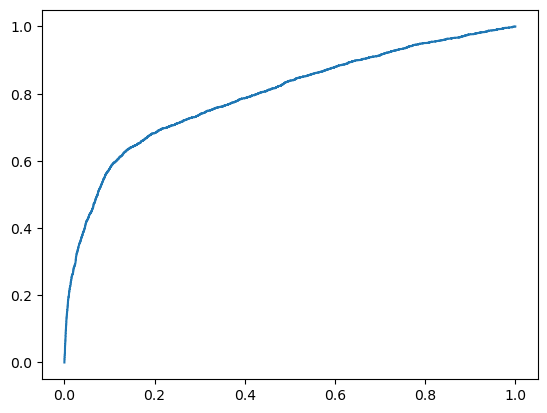

0.79593755864281


In [536]:
print(classification_report(train_preds, y_train))
print(get_auroc(y_train, train_probas))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7880
           1       0.23      0.61      0.34       358

    accuracy                           0.90      8238
   macro avg       0.61      0.76      0.64      8238
weighted avg       0.95      0.90      0.92      8238



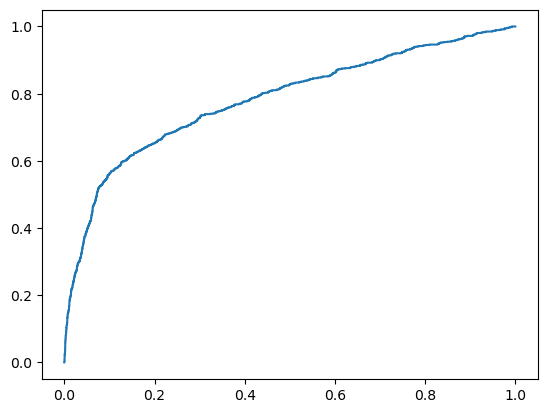

0.7826265389876881


In [537]:
print(classification_report(val_preds, y_val))
print(get_auroc(y_val, val_probas))